# **Figure 3: DGA Domain Families**

Imports

In [1]:
import kagglehub
import matplotlib.pyplot as plt
import pandas as pd

Download Benign Domains

In [2]:
cisco_path = kagglehub.dataset_download("adebayo/cisco-umbrella-list")
cisco_path += "/top-1m.csv"
print(cisco_path)

C:\Users\Admin\.cache\kagglehub\datasets\adebayo\cisco-umbrella-list\versions\1/top-1m.csv


Download Malicious DGA Domains

In [3]:
dga_path = kagglehub.dataset_download("gtkcyber/dga-dataset")
dga_path += "/dga_data.csv"
print(dga_path)

C:\Users\Admin\.cache\kagglehub\datasets\gtkcyber\dga-dataset\versions\1/dga_data.csv


Load Datasets

In [4]:
benign_domains = pd.read_csv(cisco_path, header=None)
benign_domains.columns = ["rank", "domain"]
benign_domains["label"] = 0

dga_domains = pd.read_csv(dga_path)
dga_domains["label"] = dga_domains["subclass"].apply(lambda x: 0 if x in ["alexa", "legit"] else 1)
# remove fake DGAs
dga_domains = dga_domains[dga_domains["label"] == 1]

print("Length of Benign Domain dataset:", len(benign_domains))
print("Length of DGA Domain dataset:", len(dga_domains))

benign_sample = benign_domains[["domain", "label"]]
dga_sample = dga_domains[["domain", "label"]]
benign_sampler = benign_domains[["domain", "label"]].sample(n=len(dga_sample), random_state=60)
df_full = pd.concat([benign_sample, dga_sample], ignore_index=True)
df = pd.concat([benign_sampler, dga_sample], ignore_index=True)
# Drop any rows with missing domains
print("Missing domains (benign):", benign_sample["domain"].isna().sum())
print("Missing domains (DGA):   ", dga_sample["domain"].isna().sum())
df = df.dropna(subset=["domain"]).reset_index(drop=True)
df["domain"] = df["domain"].astype(str).str.lower()
df_full = df_full.dropna(subset=["domain"]).reset_index(drop=True)
df_full["domain"] = df_full["domain"].astype(str).str.lower()

print("\nClass balance:")
print(df["label"].value_counts())
print(df["label"].value_counts(normalize=True).round(3))

Length of Benign Domain dataset: 1000000
Length of DGA Domain dataset: 80000
Missing domains (benign): 0
Missing domains (DGA):    0

Class balance:
label
0    80000
1    80000
Name: count, dtype: int64
label
0    0.5
1    0.5
Name: proportion, dtype: float64


In [5]:
print(dga_domains.columns.tolist())
print(dga_domains.head(10))

['isDGA', 'domain', 'host', 'subclass', 'label']
  isDGA                      domain                            host  \
0   dga  6xzxsw3sokvg1tc752y1a6p0af  6xzxsw3sokvg1tc752y1a6p0af.com   
1   dga              glbtlxwwhbnpxs               glbtlxwwhbnpxs.ru   
2   dga              xxmamopyipbfpk               xxmamopyipbfpk.ru   
3   dga   zfd5szpi18i85wj9uy13l69rg   zfd5szpi18i85wj9uy13l69rg.net   
4   dga                jpqftymiuver                 jpqftymiuver.ru   
5   dga                   takenroll                   takenroll.net   
6   dga                vrrtneoswsds                 vrrtneoswsds.ru   
7   dga   mzapiwbcsbqiyxnlxa1hprx8n   mzapiwbcsbqiyxnlxa1hprx8n.com   
8   dga              xkoihiygtanuio               xkoihiygtanuio.ru   
9   dga                   dreamdont                   dreamdont.net   

       subclass  label  
0   gameoverdga      1  
1  cryptolocker      1  
2  cryptolocker      1  
3        newgoz      1  
4  cryptolocker      1  
5       nivdort    

In [6]:
family_col = "subclass"

family_counts = dga_domains[family_col].value_counts()

# fig, ax = plt.subplots(figsize=(15, 10))
# family_counts.plot(kind="bar", ax=ax, color=["steelblue"])
# ax.set_xlabel("DGA Family", fontsize=13)
# ax.set_ylabel("Count", fontsize=13)
# ax.set_title("Distribution of DGA Families in the Dataset", fontsize=18, fontweight="bold")
# ax.tick_params(axis='x', rotation=45, labelsize=16)
# ax.tick_params(axis='y', labelsize=16)
# plt.tight_layout()
# plt.savefig("dga_family_distribution_fixed.pdf", format="pdf", bbox_inches="tight")
# plt.show()

print(f"\nTotal DGA families: {family_counts.nunique()}")
print(f"\nAppearing families:\n{family_counts.head(10)}")


Total DGA families: 7

Appearing families:
subclass
cryptolocker    37254
newgoz           9276
gameoverdga      8461
nivdort          8456
necurs           8331
goz              6136
bamital          2086
Name: count, dtype: int64


In [7]:
print("Sample Domain Names by DGA Family")
for family in dga_domains[family_col].unique():
    examples = dga_domains[dga_domains[family_col] == family]["domain"].head(5).tolist()
    print(f"{family:20s}: {examples}")

Sample Domain Names by DGA Family
gameoverdga         : ['6xzxsw3sokvg1tc752y1a6p0af', '1rw1pc44mkxp4qjx18qua26', '1x75xo41t4fno51wc86e1y4s13d', '1y6oppp7k3pwfpo2sfmkloyxa', '1t5fkef5u26di8wtme9ezjamn']
cryptolocker        : ['glbtlxwwhbnpxs', 'xxmamopyipbfpk', 'jpqftymiuver', 'vrrtneoswsds', 'xkoihiygtanuio']
newgoz              : ['zfd5szpi18i85wj9uy13l69rg', 'mzapiwbcsbqiyxnlxa1hprx8n', 'n3m4txqpb6a415iwzkrmdzgk6', 'wawft814u5se21tmptb51yy47q2', 'by86yc1p7f81d1tb5g7h1el8t9k']
nivdort             : ['takenroll', 'dreamdont', 'visitshot', 'mostjune', 'fairslow']
goz                 : ['rcdqeqmpxgdiuqombhuwcfu', 'jrxrovxkbemgqutopblbbfe', 'dixnzhelzukwsojfxuivlamadu', 'ydhmbyhgypnkdpzcymnnjxcalfm', 'umficyzdvcdpzbalvdmkjjvcm']
necurs              : ['sfmbdpnijlarq', 'vdqqfdcax', 'njtvrfhfaklho', 'hsmcnwof', 'mcedlrfqaqjcypqwhmio']
bamital             : ['5df9d44072820ad6eaac91669f357fea', 'a7fd378e8e64200f13421e6135a06dce', 'dd82f8a0b2b6520e2706f704ba2a289a', '08c9bb43ca6555de477ec262b

In [8]:
rows = []
for family in dga_domains[family_col].value_counts().index:
    examples = dga_domains[dga_domains[family_col] == family]["domain"].head(3).tolist()
    rows.append({
        "Family": family,
        "Count": len(dga_domains[dga_domains[family_col] == family]),
        "Example 1": examples[0] if len(examples) > 0 else "",
        "Example 2": examples[1] if len(examples) > 1 else "",
        "Example 3": examples[2] if len(examples) > 2 else "",
    })
example_table = pd.DataFrame(rows)
print(example_table.to_string(index=False))

      Family  Count                        Example 1                        Example 2                        Example 3
cryptolocker  37254                   glbtlxwwhbnpxs                   xxmamopyipbfpk                     jpqftymiuver
      newgoz   9276        zfd5szpi18i85wj9uy13l69rg        mzapiwbcsbqiyxnlxa1hprx8n        n3m4txqpb6a415iwzkrmdzgk6
 gameoverdga   8461       6xzxsw3sokvg1tc752y1a6p0af          1rw1pc44mkxp4qjx18qua26      1x75xo41t4fno51wc86e1y4s13d
     nivdort   8456                        takenroll                        dreamdont                        visitshot
      necurs   8331                    sfmbdpnijlarq                        vdqqfdcax                    njtvrfhfaklho
         goz   6136          rcdqeqmpxgdiuqombhuwcfu          jrxrovxkbemgqutopblbbfe       dixnzhelzukwsojfxuivlamadu
     bamital   2086 5df9d44072820ad6eaac91669f357fea a7fd378e8e64200f13421e6135a06dce dd82f8a0b2b6520e2706f704ba2a289a


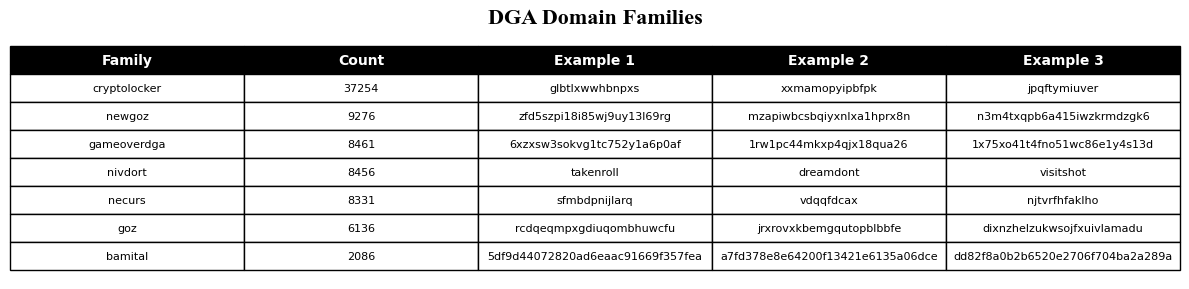

In [13]:
data = example_table.values.tolist()

col_labels = ["Family", "Count", "Example 1", "Example 2", "Example 3"]

fig, ax = plt.subplots(figsize=(12, 3))
ax.axis("off")
tbl = ax.table(
    cellText=[[str(v) for v in row] for row in data],
    colLabels=col_labels,
    loc="center",
    cellLoc="center"
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(8)
tbl.scale(1, 1.6)
for ci in range(len(col_labels)):
    tbl[(0, ci)].set_facecolor("black")
    tbl[(0, ci)].get_text().set_color("white")
    tbl[(0, ci)].get_text().set_fontweight("bold")
    tbl[(0, ci)].get_text().set_fontsize(10)
plt.title("DGA Domain Families", fontsize=16, fontfamily="Times New Roman", fontweight="bold", pad=10)
plt.tight_layout()
plt.savefig("../../figures/families.pdf", format="pdf", bbox_inches="tight")
plt.show()